# Encoder Workbench

Train, evaluate, and compare per-modality encoders (WiFi / IMU / Odometry / Vision).

**What this notebook does:**
1. Load a multi-modal dataset via `FusionDataModule` (config-driven)
2. Inspect sample shapes, distributions, and temporal structure
3. Run KNN baseline + random-encoder baseline (the floor to beat)
4. Train per-modality encoders and compare against the baselines

**Configuration lives in the next cell** — change `DATASET_CONFIG` to switch
datasets (e.g. `"simulation"` or `"imuwifine"`) and `MODALITIES` to pick a
subset of modalities, then Run All.


In [2]:
import sys, os
from pathlib import Path

# Ensure we're at the repo root regardless of where the kernel started
repo_root = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
# Fallback to the known absolute path on this machine
if not (repo_root / "configs" / "data").exists():
    repo_root = Path(r"X:\navlori-fusion")
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
print(f"Working dir: {os.getcwd()}")
print(f"torch {torch.__version__} | CUDA: {torch.cuda.is_available()}")


Working dir: x:\navlori-fusion
torch 2.6.0+cu124 | CUDA: True


## 0. Configuration — change these to switch dataset or modalities

- `DATASET_CONFIG`: name of a YAML under `configs/data/` (without `.yaml`).
  Examples: `"simulation"` (Webots, 18 paths, wifi+imu+odom[+camera]),
  `"imuwifine"` (NU C4 floor 4, 80 paths, wifi+imu).
- `MODALITIES`: `None` to use the config's default, or a list to override
  (e.g. `["wifi", "imu", "odom", "camera"]`). Modalities not present in the
  dataset will be skipped gracefully.
- `WIFI_PCA`: override the PCA dim for WiFi (overrides the YAML value).
  Set to `None` for no PCA.


In [3]:
# --- CHANGE THESE ---
DATASET_CONFIG = "simulation"       # "simulation" | "imuwifine" | "ipin2024_floor-2_intra" | "ronin_a000_intra"
MODALITIES: list[str] | None = None  # None = use YAML default, or e.g. ["wifi", "imu"]
EPOCHS = 100
EMBED_DIM = 128
BATCH_SIZE = 64
WIFI_PCA: int | None = None        # None = use YAML value; set int to override
# --------------------

from omegaconf import OmegaConf

cfg_path = Path("configs/data") / f"{DATASET_CONFIG}.yaml"
assert cfg_path.exists(), f"Config not found: {cfg_path}"
cfg = OmegaConf.load(cfg_path)
OmegaConf.resolve(cfg)  # expand ${oc.env:...} references

data_dir = Path(cfg.data.root) / cfg.data.collection_dir
train_paths = list(cfg.data.split.train_paths)
val_paths   = list(cfg.data.split.val_paths)
test_paths  = list(cfg.data.split.test_paths)

available_modalities = list(cfg.data.modalities)
if MODALITIES is None:
    active_modalities = available_modalities
else:
    requested = list(MODALITIES)
    active_modalities = [m for m in requested if m in available_modalities]
    missing = [m for m in requested if m not in available_modalities]
    if missing:
        print(f"  (skipped — not in {DATASET_CONFIG}: {missing})")

# wifi_pca: CLI override > YAML > None
yaml_pca = cfg.data.get("preprocessing", {}).get("wifi_pca", None)
wifi_pca = WIFI_PCA if WIFI_PCA is not None else yaml_pca

# windows dict (may not contain keys for every modality — FusionDataset handles defaults)
windows = dict(cfg.data.get("windows", {})) or None

print(f"Dataset:        {DATASET_CONFIG}")
print(f"Data dir:       {data_dir}")
print(f"Active modals:  {active_modalities}")
print(f"Splits:         {len(train_paths)} train / {len(val_paths)} val / {len(test_paths)} test")
print(f"WiFi PCA:       {wifi_pca}")
print(f"Windows:        {windows}")


Dataset:        simulation
Data dir:       data\async_collection
Active modals:  ['wifi', 'imu', 'odom', 'camera']
Splits:         11 train / 3 val / 3 test
WiFi PCA:       None
Windows:        {'imu': 32, 'odom': 16, 'wifi': 1, 'camera': 1}


## 1. Load the dataset

In [3]:
from src.pipeline.data import FusionDataModule

dm = FusionDataModule(
    data_dir=str(data_dir),
    train_paths=train_paths,
    val_paths=val_paths,
    test_paths=test_paths,
    modalities=active_modalities,
    windows=windows,
    batch_size=BATCH_SIZE,
    normalize=True,
    wifi_pca=wifi_pca,
)
dm.setup()
print(dm.summary())


Fusion DataModule Summary
  Train: 8542 samples
  Val: 2310 samples
  Test: 2069 samples
  Modalities: ['wifi', 'imu', 'odom', 'camera']
  Feature dims: {'wifi': 117, 'imu': 9, 'odom': 7, 'camera': (3, 480, 640)}
  Windows: {'wifi': 1, 'imu': 32, 'odom': 16, 'camera': 1}
  wifi mean range: [-88.984, -55.257]
  wifi std range:  [2.631, 12.264]
  imu mean range: [-24.669, 0.068]
  imu std range:  [0.003, 91.656]
  odom mean range: [-60.121, 2.440]
  odom std range:  [0.171, 147.311]


## 2. Inspect a single sample

Each sample is anchored to a ground-truth timestamp. The dataloader returns:
- **`imu`**: `(window, 9)` — accel_xyz, gyro_xyz, roll/pitch/yaw
- **`odom`**: `(window, 7)` — odom_xy, theta, velocities, wheel speeds
- **`wifi`**: `(1, N)` — most recent scan (N = PCA dim if enabled, else raw AP count)
- **`camera`**: `(3, H, W)` — most recent RGB frame, ImageNet-normalized
- **`target`**: `(2,)` — ground truth (x, y) in meters
- **`timestamp`**: scalar — simulation/collection time in seconds

Modalities absent from the current config are omitted silently.


In [4]:
sample = dm.train_ds[100]

print("Keys:", list(sample.keys()))
print()
for key in active_modalities:
    if key not in sample:
        continue
    t = sample[key]
    print(f"{key:8s}  shape={str(list(t.shape)):20s}  dtype={t.dtype}  range=[{t.min():.3f}, {t.max():.3f}]")
print(f"\ntarget  (x, y) = ({sample['target'][0]:.2f}, {sample['target'][1]:.2f}) m")
print(f"timestamp = {sample['timestamp']:.3f} s")
print(f"path_id   = {sample['path_id']}")


Keys: ['target', 'timestamp', 'path_id', 'wifi', 'imu', 'odom', 'camera']

wifi      shape=[1, 117]              dtype=torch.float32  range=[-2.875, 3.134]
imu       shape=[32, 9]               dtype=torch.float32  range=[-0.175, 0.616]
odom      shape=[16, 7]               dtype=torch.float32  range=[-0.006, 0.417]
camera    shape=[3, 480, 640]         dtype=torch.float32  range=[-1.895, 2.379]

target  (x, y) = (-4.18, -16.34) m
timestamp = 63.040 s
path_id   = 1


## 3. Inspect a batch (from DataLoader)

In [5]:
train_loader = dm.train_dataloader()
batch = next(iter(train_loader))

print(f"Batch size: {batch['target'].shape[0]}")
print()
for key in active_modalities + ["target"]:
    if key in batch:
        print(f"{key:8s}  {list(batch[key].shape)}")


Batch size: 64

wifi      [64, 1, 117]
imu       [64, 32, 9]
odom      [64, 16, 7]
camera    [64, 3, 480, 640]
target    [64, 2]


## 4. Visualize modality windows

Plot what each encoder "sees" for a single sample. Grid size adapts to the
active modalities.


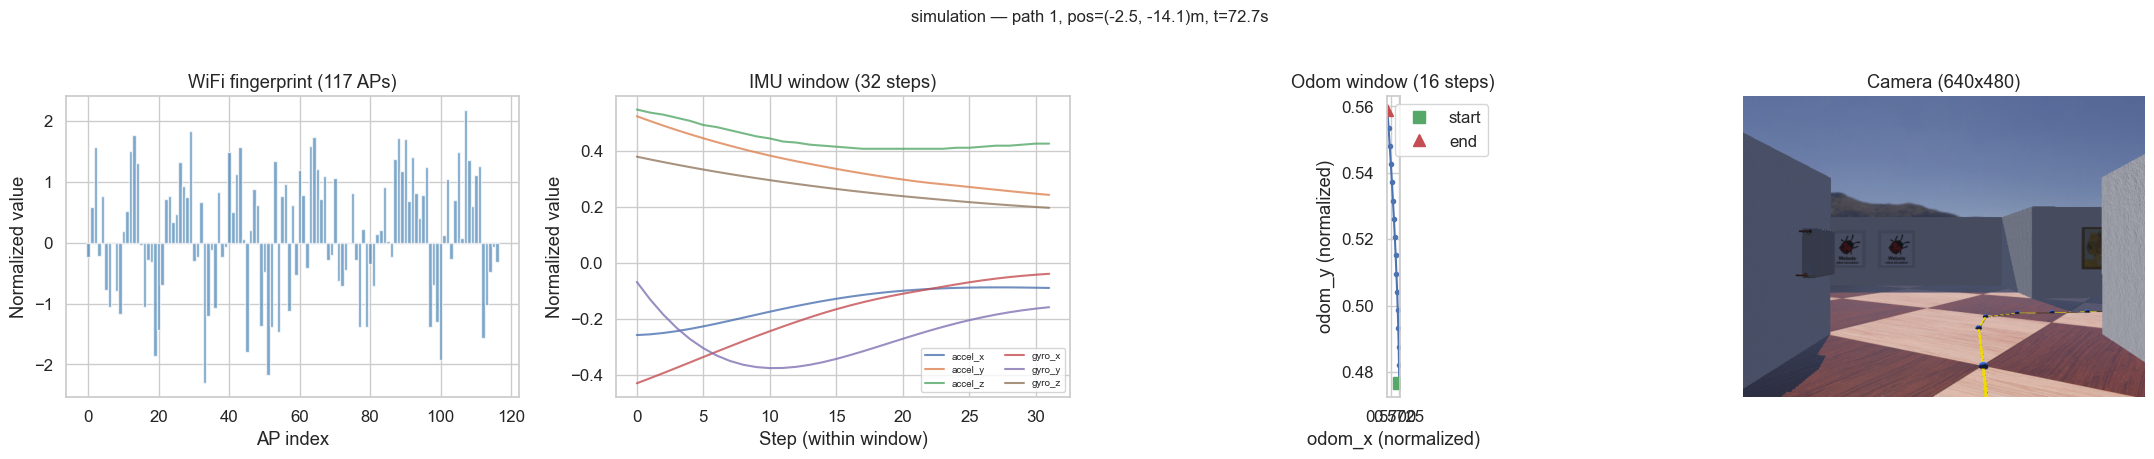

In [6]:
from src.pipeline.data.dataset import IMU_COLS, ODOM_COLS

sample = dm.train_ds[min(200, len(dm.train_ds) - 1)]

panels = [m for m in active_modalities if m in sample]
if len(panels) == 0:
    print("No active modalities to plot.")
else:
    ncols = len(panels)
    fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4.5))
    if ncols == 1:
        axes = [axes]

    for ax, mod in zip(axes, panels):
        data = sample[mod].numpy()
        if mod == "imu":
            for i, col in enumerate(IMU_COLS[:6]):  # accel + gyro
                ax.plot(data[:, i], label=col, alpha=0.8)
            ax.set_title(f"IMU window ({data.shape[0]} steps)")
            ax.set_xlabel("Step (within window)")
            ax.set_ylabel("Normalized value")
            ax.legend(fontsize=7, ncol=2)
        elif mod == "odom":
            ax.plot(data[:, 0], data[:, 1], "o-", markersize=3)
            ax.plot(data[0, 0], data[0, 1], "gs", markersize=8, label="start")
            ax.plot(data[-1, 0], data[-1, 1], "r^", markersize=8, label="end")
            ax.set_title(f"Odom window ({data.shape[0]} steps)")
            ax.set_xlabel("odom_x (normalized)")
            ax.set_ylabel("odom_y (normalized)")
            ax.legend()
            ax.set_aspect("equal")
        elif mod == "wifi":
            vec = data.flatten()
            ax.bar(range(len(vec)), vec, width=1.0, color="steelblue", alpha=0.7)
            n_label = f"{len(vec)} PCA dims" if dm.wifi_pca else f"{len(vec)} APs"
            ax.set_title(f"WiFi fingerprint ({n_label})")
            ax.set_xlabel("Component" if dm.wifi_pca else "AP index")
            ax.set_ylabel("Normalized value")
        elif mod == "camera":
            mean = np.array([0.485, 0.456, 0.406])[:, None, None]
            std  = np.array([0.229, 0.224, 0.225])[:, None, None]
            cam_display = np.clip(data * std + mean, 0, 1).transpose(1, 2, 0)
            ax.imshow(cam_display)
            ax.set_title(f"Camera ({data.shape[2]}x{data.shape[1]})")
            ax.axis("off")

    fig.suptitle(
        f"{DATASET_CONFIG} — path {sample['path_id']}, "
        f"pos=({sample['target'][0]:.1f}, {sample['target'][1]:.1f})m, "
        f"t={sample['timestamp']:.1f}s",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()


## 5. Target distribution (ground truth positions)

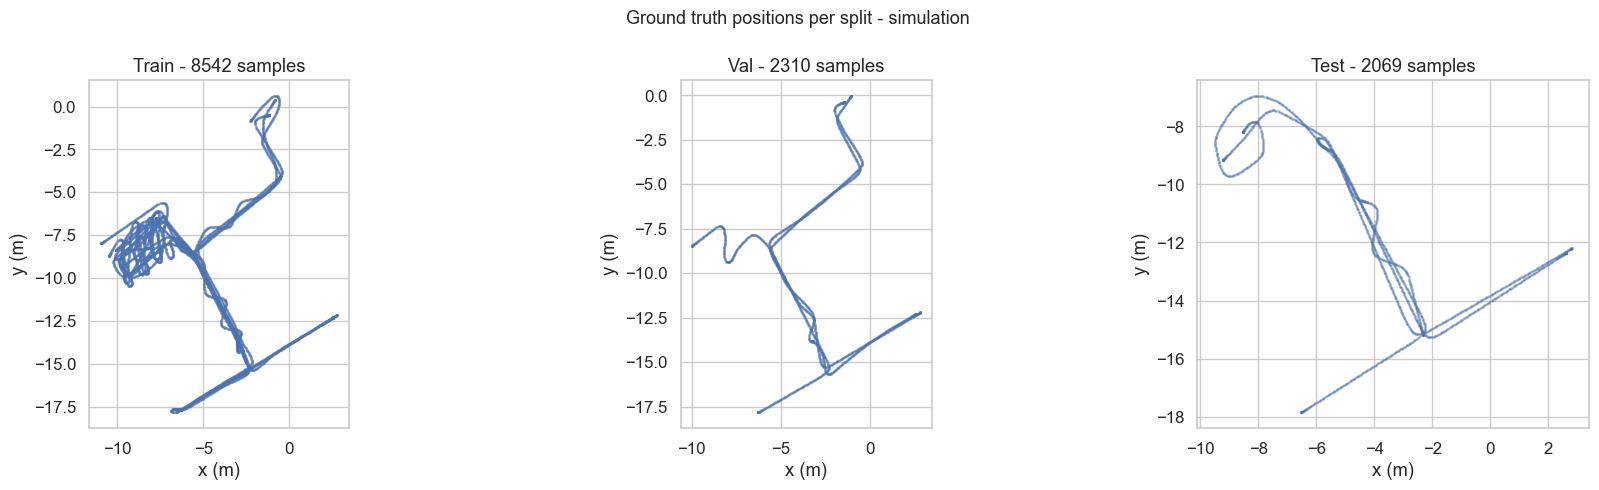

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, ds) in zip(axes, [("Train", dm.train_ds), ("Val", dm.val_ds), ("Test", dm.test_ds)]):
    targets = np.array([ds[i]["target"].numpy() for i in range(len(ds))])
    ax.scatter(targets[:, 0], targets[:, 1], s=1, alpha=0.3)
    ax.set_title(f"{name} - {len(ds)} samples")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")

plt.suptitle(f"Ground truth positions per split - {DATASET_CONFIG}", fontsize=13)
plt.tight_layout()
plt.show()


## 6. Normalization stats

Training-set stats are reused for val/test (no leakage).


In [8]:
import pandas as pd

TABULAR = [m for m in active_modalities if m != "camera"]

for mod in TABULAR:
    if mod not in dm.train_ds.stats:
        continue
    stats = dm.train_ds.stats[mod]
    if mod == "imu":
        cols = IMU_COLS
    elif mod == "odom":
        cols = ODOM_COLS
    elif mod == "wifi":
        n = len(stats["mean"])
        cols = [f"PC_{i}" for i in range(n)] if dm.wifi_pca else [f"AP_{i}" for i in range(n)]
    else:
        cols = [f"f_{i}" for i in range(len(stats["mean"]))]

    df = pd.DataFrame({"feature": cols, "mean": stats["mean"], "std": stats["std"]})
    print(f"\n{'='*50}")
    print(f"  {mod.upper()} normalization stats ({len(cols)} features)")
    print(f"{'='*50}")
    # Truncate if many features
    if len(df) > 40:
        print(df.head(20).to_string(index=False, float_format="{:.4f}".format))
        print(f"  ... ({len(df) - 20} more features)")
    else:
        print(df.to_string(index=False, float_format="{:.4f}".format))



  WIFI normalization stats (117 features)
feature     mean     std
   AP_0 -74.0857  9.4681
   AP_1 -74.7401  9.3410
   AP_2 -74.0638  8.9609
   AP_3 -74.4386  9.0681
   AP_4 -72.5987  9.1290
   AP_5 -69.6573  9.3019
   AP_6 -70.0723  9.5429
   AP_7 -70.6770  8.7662
   AP_8 -71.1229  8.3138
   AP_9 -70.2838  9.2751
  AP_10 -86.6657  2.9363
  AP_11 -86.2587  2.9329
  AP_12 -86.3575  3.4827
  AP_13 -86.7279  3.9707
  AP_14 -86.3455  3.3742
  AP_15 -61.6312  9.7155
  AP_16 -61.1357  9.5824
  AP_17 -61.6357  9.9664
  AP_18 -61.9743 10.3298
  AP_19 -62.0594 10.0022
  ... (97 more features)

  IMU normalization stats (9 features)
  feature     mean     std
  accel_x   0.0684  0.1123
  accel_y  -0.0207  0.1729
  accel_z  -0.0014  0.0027
   gyro_x  -0.0002  0.0093
   gyro_y   0.0025  0.0142
   gyro_z  -0.0262  0.3835
 roll_deg  -0.0789  0.3788
pitch_deg  -0.3799  0.2132
  yaw_deg -24.6687 91.6559

  ODOM normalization stats (7 features)
         feature     mean      std
          odom_x   2.

## 9. Evaluation harness — dummy encoder baseline

Run all 6 metrics on a **random linear encoder**. Any trained encoder must beat
these numbers. Camera is skipped (raw pixels through a random projection are
not meaningful).


In [9]:
import torch.nn as nn
from src.pipeline.evaluation import evaluate_encoder, print_report

class DummyEncoder(nn.Module):
    """Random linear projection — the baseline any real encoder should beat."""
    def __init__(self, input_dim, embed_dim=64):
        super().__init__()
        self.flatten = nn.Flatten()
        self.proj = nn.Linear(input_dim, embed_dim)
    def forward(self, x):
        return self.proj(self.flatten(x))

TABULAR = [m for m in active_modalities if m != "camera"]

dm_eval = FusionDataModule(
    data_dir=str(data_dir),
    train_paths=train_paths, val_paths=val_paths, test_paths=test_paths,
    modalities=TABULAR,
    windows=windows,
    batch_size=512,
    num_workers=0,
    normalize=True,
    wifi_pca=wifi_pca,
)
dm_eval.setup()
eval_train_loader = dm_eval.train_dataloader()
eval_val_loader   = dm_eval.val_dataloader()


In [10]:
# Feature dims per modality (flattened window * features)
feat_dims = dm_eval.train_ds.feature_dims
win = dm_eval.train_ds.windows

def input_dim_for(mod: str) -> int:
    fd = feat_dims[mod]
    if isinstance(fd, tuple):  # camera
        import math
        return math.prod(fd)
    return win[mod] * fd

all_results = {}
for mod in TABULAR:
    in_dim = input_dim_for(mod)
    print(f"\n>>> Evaluating dummy encoder for: {mod} (input_dim={in_dim})")
    encoder = DummyEncoder(input_dim=in_dim, embed_dim=64)
    results = evaluate_encoder(
        encoder=encoder,
        train_loader=eval_train_loader,
        val_loader=eval_val_loader,
        modality=mod,
    )
    print_report(results, modality=mod)
    all_results[mod] = results



>>> Evaluating dummy encoder for: wifi (input_dim=117)

  Encoder Evaluation Report — wifi
  Linear Probe:     MAE=6.529m  RMSE=7.746m  Euclid=10.271m
  KNN Probe (k=5):  MAE=0.824m  Euclid=1.264m
  Alignment:        1.1578  (lower=better)
  Uniformity:       -3.1311  (lower=better)
  Effective Dim:    PR=11.1/64  95%var=39 dims
  Temporal Smooth:  corr=0.151  mean_dz=0.4796


>>> Evaluating dummy encoder for: imu (input_dim=288)

  Encoder Evaluation Report — imu
  Linear Probe:     MAE=6.495m  RMSE=8.121m  Euclid=10.548m
  KNN Probe (k=5):  MAE=2.655m  Euclid=4.089m
  Alignment:        1.6713  (lower=better)
  Uniformity:       -1.8549  (lower=better)
  Effective Dim:    PR=6.7/64  95%var=11 dims
  Temporal Smooth:  corr=0.048  mean_dz=0.8753


>>> Evaluating dummy encoder for: odom (input_dim=112)

  Encoder Evaluation Report — odom
  Linear Probe:     MAE=6.503m  RMSE=8.062m  Euclid=10.457m
  KNN Probe (k=5):  MAE=3.156m  Euclid=5.150m
  Alignment:        1.3027  (lower=better)
  

In [11]:
header = f"{'Modality':>10} | {'LP MAE':>8} | {'LP Euclid':>10} | {'KNN MAE':>8} | {'Align':>8} | {'Uniform':>9} | {'Eff.Dim':>10} | {'Temporal':>8}"
print(header)
print("-" * len(header))
for mod, res in all_results.items():
    lp, kp, au, ed, ts = (res["linear_probe"], res["knn_probe"],
                          res["alignment_uniformity"], res["effective_dimensionality"],
                          res["temporal_smoothness"])
    print(f"{mod:>10} | {lp['mae']:>7.3f}m | {lp['mean_euclidean']:>9.3f}m | "
          f"{kp['mae']:>7.3f}m | {au['alignment']:>8.4f} | {au['uniformity']:>9.4f} | "
          f"{ed['participation_ratio']:>6.1f}/{ed['embed_dim']:<3d} | {ts['correlation']:>8.3f}")

print("\nThese are RANDOM BASELINE numbers. Any trained encoder must beat them.")


  Modality |   LP MAE |  LP Euclid |  KNN MAE |    Align |   Uniform |    Eff.Dim | Temporal
--------------------------------------------------------------------------------------------
      wifi |   6.529m |    10.271m |   0.824m |   1.1578 |   -3.1311 |   11.1/64  |    0.151
       imu |   6.495m |    10.548m |   2.655m |   1.6713 |   -1.8549 |    6.7/64  |    0.048
      odom |   6.503m |    10.457m |   3.156m |   1.3027 |   -1.8705 |    3.3/64  |    0.533

These are RANDOM BASELINE numbers. Any trained encoder must beat them.


## 10. Train encoders

Each modality gets its own encoder; training is driven by an encoder registry
so adding a new modality is a one-line change.

Training config: AdamW (lr=1e-3), Huber loss, OneCycleLR, gradient clipping,
early stopping (patience=25).


In [12]:
from src.pipeline.encoders import Anchor2Vec, IMUCNN, OdomCNN
from src.pipeline.training import EncoderTrainer

# Registry: modality -> encoder factory taking feat_dim (input feature count)
ENCODER_REGISTRY = {
    "wifi":   lambda feat_dim: Anchor2Vec(n_aps=feat_dim, embed_dim=EMBED_DIM, n_anchors=64),
    # "imu":    lambda feat_dim: IMUCNN(in_features=feat_dim, embed_dim=EMBED_DIM),
    # "odom":   lambda feat_dim: OdomCNN(in_features=feat_dim, embed_dim=EMBED_DIM),
}

trained_results = {}
histories = {}
trained_encoders = {}


In [13]:
TABULAR = [m for m in active_modalities if m != "camera"]

for mod in TABULAR:
    if mod not in ENCODER_REGISTRY:
        print(f"  [skip] no encoder registered for '{mod}'")
        continue
    feat_dim = dm_eval.train_ds.feature_dims[mod]
    print(f"\n=== Training {mod} (feat_dim={feat_dim}) ===")
    encoder = ENCODER_REGISTRY[mod](feat_dim)
    n_params = sum(p.numel() for p in encoder.parameters())
    print(f"  {mod} encoder: {n_params:,} params")

    trainer = EncoderTrainer(encoder, modality=mod, dm=dm_eval, patience=25)
    histories[mod] = trainer.fit(epochs=EPOCHS)
    trained_results[mod] = trainer.evaluate()
    trained_encoders[mod] = trainer.encoder



=== Training wifi (feat_dim=117) ===
  wifi encoder: 49,217 params
  Epoch   0/100  train_loss=2.9235  val_loss=2.2682  val_mae=7.950m  lr=4.26e-05  *
  Epoch  10/100  train_loss=0.5919  val_loss=0.6492  val_mae=2.532m  lr=3.26e-04  *
  Epoch  20/100  train_loss=0.0797  val_loss=0.1882  val_mae=0.890m  lr=8.04e-04  *
  Epoch  30/100  train_loss=0.0325  val_loss=0.1397  val_mae=0.719m  lr=9.99e-04  
  Epoch  40/100  train_loss=0.0175  val_loss=0.1280  val_mae=0.670m  lr=9.40e-04  *
  Epoch  50/100  train_loss=0.0121  val_loss=0.1334  val_mae=0.690m  lr=7.93e-04  
  Epoch  60/100  train_loss=0.0104  val_loss=0.1337  val_mae=0.691m  lr=5.88e-04  
  Epoch  65/100  train_loss=0.0097  val_loss=0.1334  val_mae=0.691m  lr=4.76e-04  
  Early stopping at epoch 65 (best=40)
  Done in 12.3s — best val MAE: 0.670m (epoch 40)

  Encoder Evaluation Report — wifi
  Linear Probe:     MAE=2.042m  RMSE=2.890m  Euclid=3.319m
  KNN Probe (k=5):  MAE=0.407m  Euclid=0.620m
  Alignment:        0.0389  (lower

### 10a. Comparison — trained vs. random baseline

In [14]:
header = (f"{'Modality':>10} | {'':^15s} | {'LP MAE':>8} | {'LP Euclid':>10} | "
          f"{'KNN MAE':>8} | {'Align':>8} | {'Uniform':>9} | {'Eff.Dim':>10} | {'Temporal':>8}")
print(header)
print("-" * len(header))

for mod in active_modalities:
    for label, src in [("random", all_results), ("trained", trained_results)]:
        if mod not in src:
            continue
        res = src[mod]
        lp, kp, au, ed, ts = (res["linear_probe"], res["knn_probe"],
                              res["alignment_uniformity"], res["effective_dimensionality"],
                              res["temporal_smoothness"])
        print(f"{mod:>10} | {label:^15s} | {lp['mae']:>7.3f}m | {lp['mean_euclidean']:>9.3f}m | "
              f"{kp['mae']:>7.3f}m | {au['alignment']:>8.4f} | {au['uniformity']:>9.4f} | "
              f"{ed['participation_ratio']:>6.1f}/{ed['embed_dim']:<3d} | {ts['correlation']:>8.3f}")
    print()


  Modality |                 |   LP MAE |  LP Euclid |  KNN MAE |    Align |   Uniform |    Eff.Dim | Temporal
--------------------------------------------------------------------------------------------------------------
      wifi |     random      |   6.529m |    10.271m |   0.824m |   1.1578 |   -3.1311 |   11.1/64  |    0.151
      wifi |     trained     |   2.042m |     3.319m |   0.407m |   0.0389 |   -1.0490 |    2.7/128 |    0.490

       imu |     random      |   6.495m |    10.548m |   2.655m |   1.6713 |   -1.8549 |    6.7/64  |    0.048

      odom |     random      |   6.503m |    10.457m |   3.156m |   1.3027 |   -1.8705 |    3.3/64  |    0.533




### 10b. Training curves

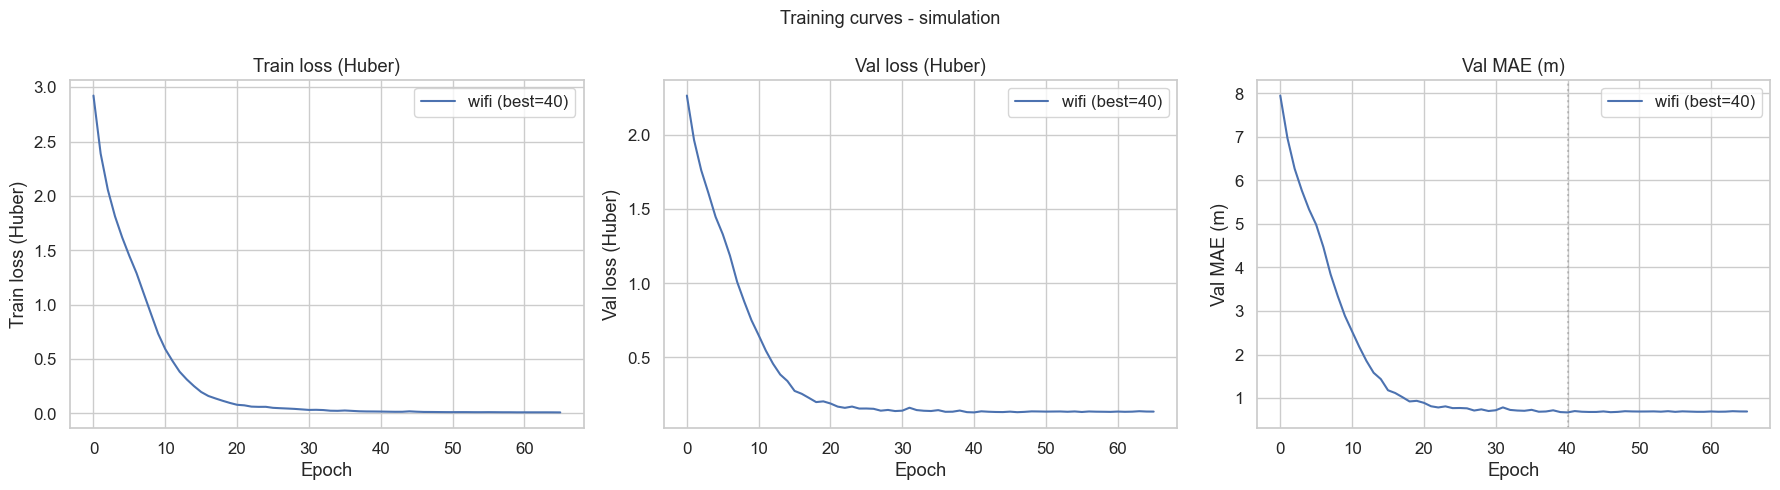


--- Training summary ---
  wifi    best_epoch= 40  best_val_mae=0.670m  time=12.3s


In [15]:
if len(histories) == 0:
    print("No trained encoders — skip.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, metric, ylabel in zip(
        axes,
        ["train_loss", "val_loss", "val_mae"],
        ["Train loss (Huber)", "Val loss (Huber)", "Val MAE (m)"],
    ):
        for mod, h in histories.items():
            values = getattr(h, metric)
            ax.plot(values, label=f"{mod} (best={h.best_epoch})")
            if metric == "val_mae":
                ax.axvline(h.best_epoch, color="gray", linestyle=":", alpha=0.4)
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(ylabel); ax.legend()

    plt.suptitle(f"Training curves - {DATASET_CONFIG}", fontsize=13)
    plt.tight_layout()
    plt.show()

    print("\n--- Training summary ---")
    for mod, h in histories.items():
        print(f"  {mod:6s}  best_epoch={h.best_epoch:3d}  best_val_mae={h.best_val_mae:.3f}m  time={h.elapsed_sec:.1f}s")


## 11. WiFi encoder diagnostics

Quick visual checks on what the trained WiFi encoder actually learned.

- **PCA of embeddings** — colored by ground-truth `x` (then `y`). If the
  encoder picked up spatial structure, you should see a smooth color
  gradient across the projection.
- **Predicted vs. actual position** — a Ridge linear probe on the
  embeddings + arrows from actual → predicted on the val map.
- **Spatial error map** — per-sample Euclidean error plotted at the
  actual position; reveals which areas of the floor the encoder
  struggles with.
- **Distance preservation** — sampled pairs, embedding distance vs.
  metric distance. A monotone trend means the embedding metric is
  geometry-aware.


In [16]:
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

if "wifi" not in trained_encoders:
    raise RuntimeError("WiFi encoder is not in trained_encoders — "
                       "run section 10 first with 'wifi' in MODALITIES.")

_wifi_enc = trained_encoders["wifi"].eval()
_device = next(_wifi_enc.parameters()).device

@torch.no_grad()
def _embed(ds):
    X, y = ds.get_tensors("wifi")
    z = _wifi_enc(X.to(_device)).cpu().numpy()
    return z, y.numpy()

Z_tr, Y_tr = _embed(dm_eval.train_ds)
Z_va, Y_va = _embed(dm_eval.val_ds)
print(f"train: Z={Z_tr.shape} Y={Y_tr.shape}   val: Z={Z_va.shape} Y={Y_va.shape}")


train: Z=(8542, 128) Y=(8542, 2)   val: Z=(2310, 128) Y=(2310, 2)


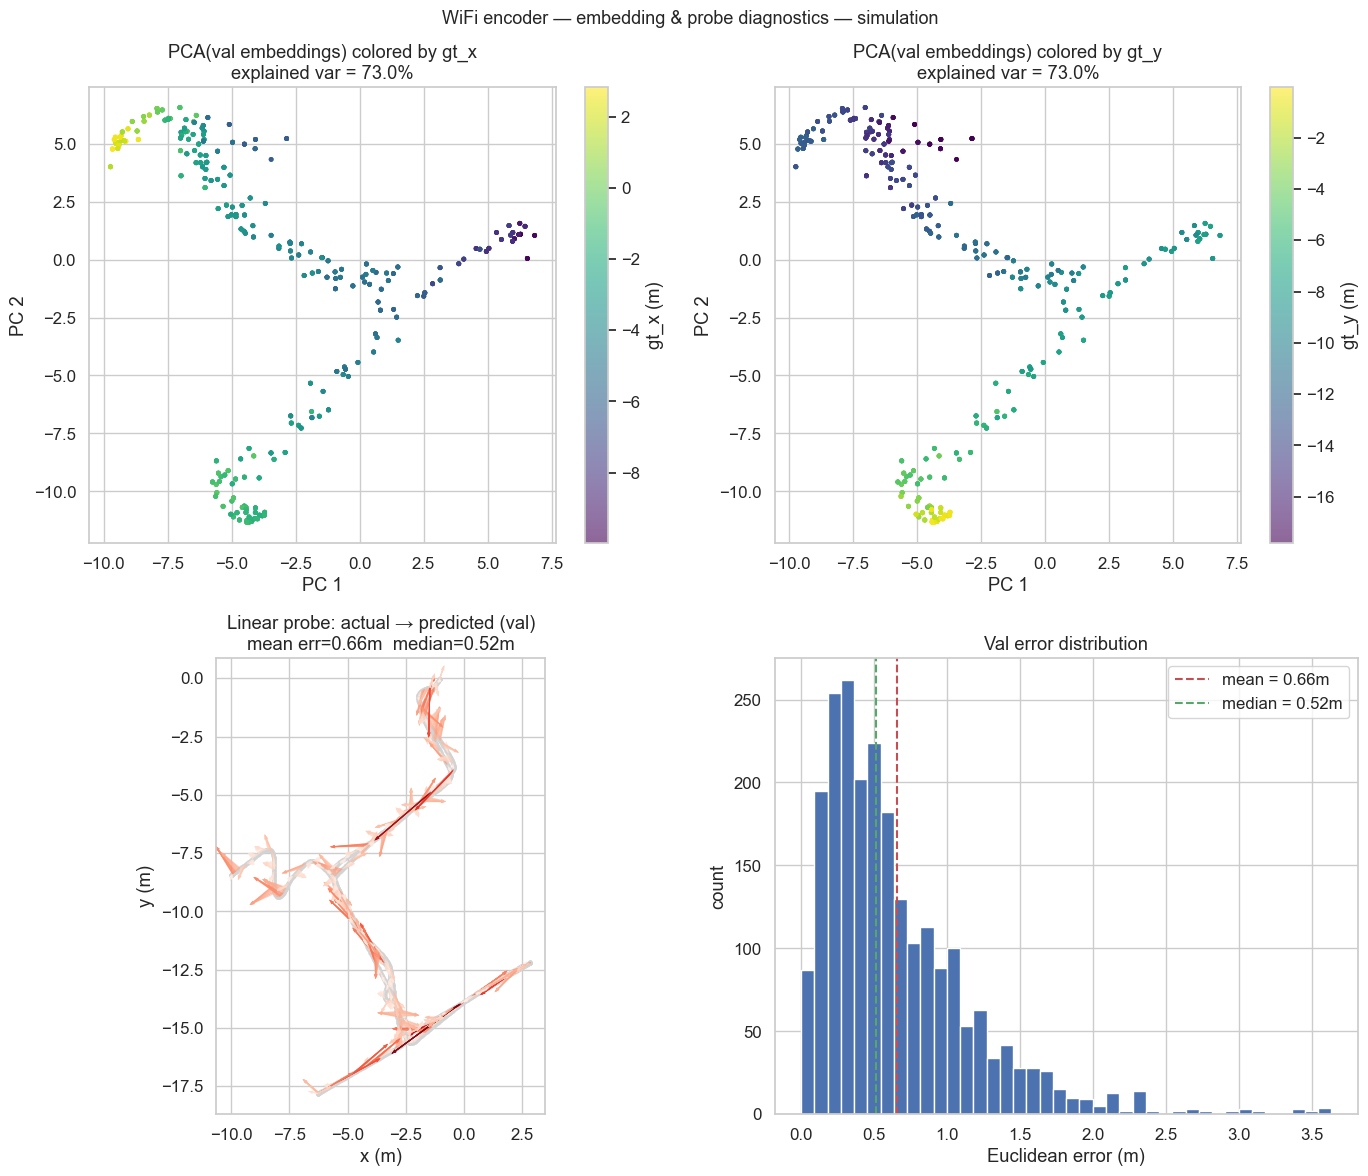

In [17]:
_pca = PCA(n_components=2)
_Z2_tr = _pca.fit_transform(Z_tr)
_Z2_va = _pca.transform(Z_va)

_probe = Ridge(alpha=1.0).fit(Z_tr, Y_tr)
_Y_va_hat = _probe.predict(Z_va)
_err = np.linalg.norm(_Y_va_hat - Y_va, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Row 1: PCA colored by gt_x and gt_y
for ax, axis_idx, axis_name in zip(axes[0], [0, 1], ["x", "y"]):
    sc = ax.scatter(_Z2_va[:, 0], _Z2_va[:, 1], c=Y_va[:, axis_idx],
                    cmap="viridis", s=6, alpha=0.6)
    plt.colorbar(sc, ax=ax, label=f"gt_{axis_name} (m)")
    ax.set_title(f"PCA(val embeddings) colored by gt_{axis_name}\n"
                 f"explained var = {_pca.explained_variance_ratio_.sum():.1%}")
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")

# Row 2 left: predicted ← actual on the floor
ax = axes[1][0]
ax.scatter(Y_va[:, 0], Y_va[:, 1], s=4, c="lightgray", label="val targets")
ax.quiver(Y_va[:, 0], Y_va[:, 1],
          _Y_va_hat[:, 0] - Y_va[:, 0],
          _Y_va_hat[:, 1] - Y_va[:, 1],
          _err, cmap="Reds", angles="xy", scale_units="xy", scale=1,
          width=0.003, alpha=0.6)
ax.set_title(f"Linear probe: actual → predicted (val)\n"
             f"mean err={_err.mean():.2f}m  median={np.median(_err):.2f}m")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_aspect("equal")

# Row 2 right: error histogram
ax = axes[1][1]
ax.hist(_err, bins=40, edgecolor="white")
ax.axvline(_err.mean(), c="r", ls="--", label=f"mean = {_err.mean():.2f}m")
ax.axvline(np.median(_err), c="g", ls="--", label=f"median = {np.median(_err):.2f}m")
ax.set_xlabel("Euclidean error (m)"); ax.set_ylabel("count")
ax.set_title("Val error distribution"); ax.legend()

plt.suptitle(f"WiFi encoder — embedding & probe diagnostics — {DATASET_CONFIG}", fontsize=13)
plt.tight_layout(); plt.show()


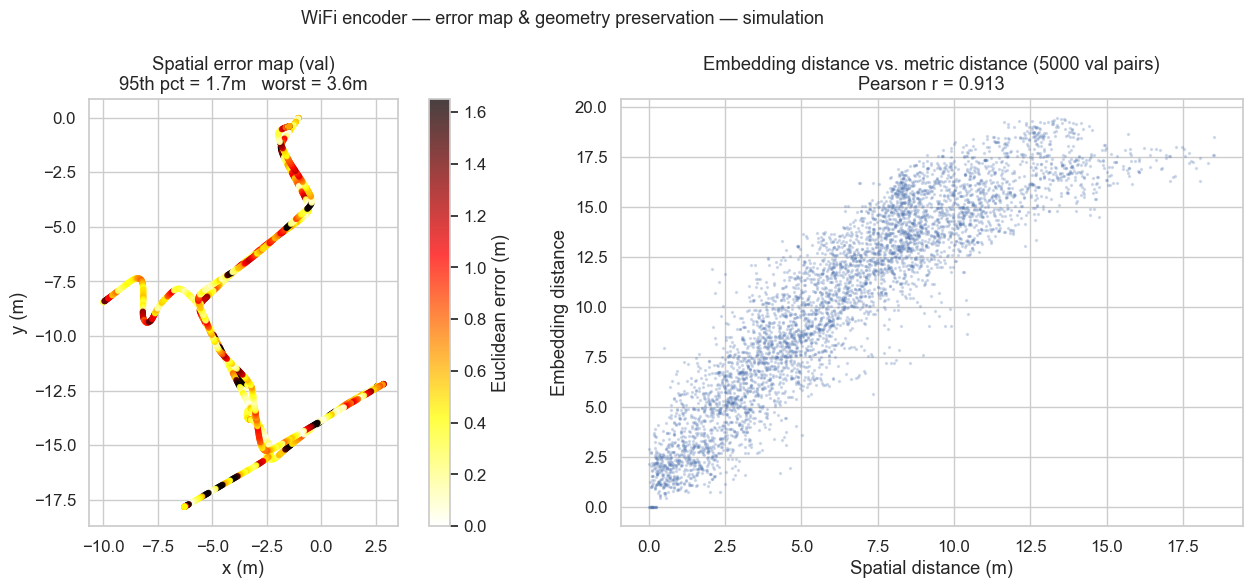

In [18]:
rng = np.random.default_rng(0)
_n_pairs = min(5000, len(Z_va) * (len(Z_va) - 1) // 2)
_i = rng.integers(0, len(Z_va), _n_pairs)
_j = rng.integers(0, len(Z_va), _n_pairs)
_keep = _i != _j
_i, _j = _i[_keep], _j[_keep]

_emb_d = np.linalg.norm(Z_va[_i] - Z_va[_j], axis=1)
_spa_d = np.linalg.norm(Y_va[_i] - Y_va[_j], axis=1)
_corr = float(np.corrcoef(_spa_d, _emb_d)[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
sc = ax.scatter(Y_va[:, 0], Y_va[:, 1], c=_err, cmap="hot_r", s=12, alpha=0.75,
                vmin=0, vmax=np.percentile(_err, 95))
plt.colorbar(sc, ax=ax, label="Euclidean error (m)")
ax.set_title(f"Spatial error map (val)\n"
             f"95th pct = {np.percentile(_err, 95):.1f}m   worst = {_err.max():.1f}m")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_aspect("equal")

ax = axes[1]
ax.scatter(_spa_d, _emb_d, s=2, alpha=0.2)
ax.set_xlabel("Spatial distance (m)")
ax.set_ylabel("Embedding distance")
ax.set_title(f"Embedding distance vs. metric distance ({len(_i)} val pairs)\n"
             f"Pearson r = {_corr:.3f}")

plt.suptitle(f"WiFi encoder — error map & geometry preservation — {DATASET_CONFIG}",
             fontsize=13)
plt.tight_layout(); plt.show()


## 12. Camera encoder — DPVO motion encoder (visual odometry)

`DPVOMotionEncoder` — DPVO's frozen TartanAir-pretrained patch trunk used
as a **visual-odometry** encoder. For a frame pair it samples patches in
frame *t−1*, locates each one in frame *t* by **local cosine correlation
+ windowed soft-argmax**, and a trainable head regresses the world-frame
displacement **(dx, dy)** over the pair.

Unlike the place-recognition encoders (WiFi / ACE), this one predicts
*motion*. At inference we **dead-reckon**: take a single ground-truth
position at frame 0 and accumulate predicted displacements — no other
sensor, no filter. World-frame Δ means heading is re-derived per frame
from appearance, so there is no heading-integration drift, only a
translation random-walk.

Three deliverables below: **(1)** training curves, **(2)** a full path
dead-reckoned from one GT anchor, **(3)** patch correspondence across an
image sequence.


In [4]:
# --- 12.0 Train the motion head -------------------------------------
# Caches the encoder's frozen per-patch motion tokens for the train/val
# split, then trains only the delta head (standardised-target Huber).
from pathlib import Path
import numpy as np
import torch

from src.pipeline.encoders.dpvo_motion import DPVOMotionEncoder
from src.pipeline.training.motion import (
    cache_tokens, DeltaRegressor, train_delta_head,
)

DATA = Path("data/async_collection")
STRIDE = 5                                   # frame-pair gap (~1 s of motion)
TRAIN_PATHS = [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
VAL_PATHS = [2, 13, 14]
device = "cuda" if torch.cuda.is_available() else "cpu"

motion_enc = DPVOMotionEncoder(
    weights_path="runs/_weights/dpvo.pth").to(device).eval()

tr_dirs = [DATA / f"path_{p:02d}" for p in TRAIN_PATHS]
va_dirs = [DATA / f"path_{p:02d}" for p in VAL_PATHS]
tok_tr, dlt_tr, _ = cache_tokens(motion_enc, tr_dirs, STRIDE, device)
tok_va, dlt_va, _ = cache_tokens(motion_enc, va_dirs, STRIDE, device)
print(f"\ntrain={tok_tr.shape[0]}  val={tok_va.shape[0]} frame-pairs")

motion_reg = DeltaRegressor(motion_enc.head, embed_dim=motion_enc.embed_dim)
motion_history = train_delta_head(
    motion_reg, tok_tr, dlt_tr, tok_va, dlt_va,
    epochs=150, lr=1e-3, patience=30, device=device,
)


[cache] path_01: 375 pairs (17.8s)
[cache] path_03: 364 pairs (15.9s)
[cache] path_04: 226 pairs (10.1s)
[cache] path_05: 288 pairs (12.9s)
[cache] path_06: 336 pairs (14.9s)
[cache] path_07: 524 pairs (23.3s)
[cache] path_08: 579 pairs (25.9s)
[cache] path_09: 458 pairs (19.9s)
[cache] path_10: 243 pairs (10.9s)
[cache] path_11: 490 pairs (21.5s)
[cache] path_12: 324 pairs (14.2s)
[cache] path_02: 424 pairs (18.5s)
[cache] path_13: 320 pairs (14.0s)
[cache] path_14: 395 pairs (17.1s)

train=4207  val=1139 frame-pairs
  ep   0/150  train=0.0856  val=0.0874  val_MAE=0.311m *
  ep   1/150  train=0.0834  val=0.0860  val_MAE=0.310m *
  ep   2/150  train=0.0818  val=0.0865  val_MAE=0.309m *
  ep   3/150  train=0.0794  val=0.0825  val_MAE=0.309m *
  ep   4/150  train=0.0738  val=0.0693  val_MAE=0.256m *
  ep   5/150  train=0.0632  val=0.0571  val_MAE=0.212m *
  ep   6/150  train=0.0557  val=0.0523  val_MAE=0.201m *
  ep   7/150  train=0.0548  val=0.0502  val_MAE=0.188m *
  ep   8/150  train=

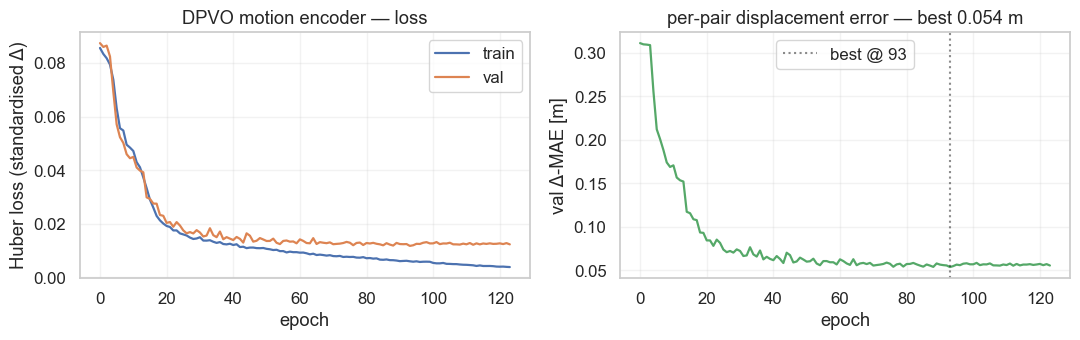

best val Δ-MAE = 0.054 m  (mean motion per pair ≈ 0.309 m)


In [5]:
# --- 12.1  DELIVERABLE 1 — training curves --------------------------
import matplotlib.pyplot as plt

h = motion_history
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(h.train_loss, label="train", lw=1.6)
axes[0].plot(h.val_loss,   label="val",   lw=1.6)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("Huber loss (standardised Δ)")
axes[0].set_title("DPVO motion encoder — loss")
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(h.val_mae, color="C2", lw=1.6)
axes[1].axvline(h.best_epoch, color="k", ls=":", alpha=0.5,
                label=f"best @ {h.best_epoch}")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val Δ-MAE [m]")
axes[1].set_title(f"per-pair displacement error — best {h.best_val_mae:.3f} m")
axes[1].legend(); axes[1].grid(alpha=0.25)

plt.tight_layout(); plt.show()
print(f"best val Δ-MAE = {h.best_val_mae:.3f} m  (mean motion per pair ≈ "
      f"{dlt_va.norm(dim=1).mean():.3f} m)")


    path  segments  mean err  final drift  path len  drift %
 path_02        85     0.58m        1.33m     25.7m    5.2%
 path_13        64     0.22m        0.20m     19.7m    1.0%
 path_14        79     1.06m        1.46m     25.1m    5.8%


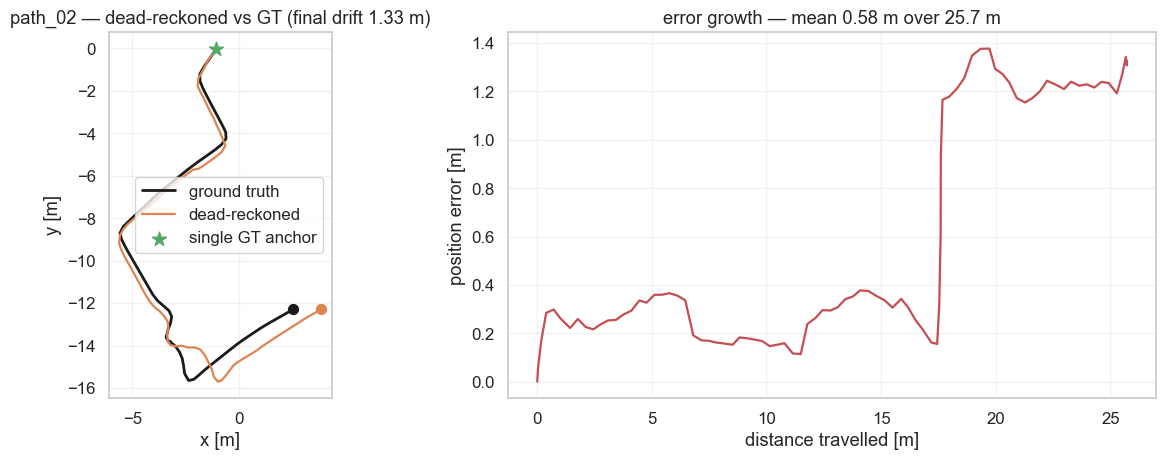

In [6]:
# --- 12.2  DELIVERABLE 2 — dead-reckoned path from ONE GT anchor ----
# Online scenario: position at frame 0 is the only ground truth given;
# every later position is the previous one + the encoder's predicted
# displacement. Non-overlapping STRIDE segments tile the path exactly.
import numpy as np
import matplotlib.pyplot as plt
from src.pipeline.training.motion import deadreckon_path

# Drift summary for every validation path.
print(f"{'path':>8} {'segments':>9} {'mean err':>9} {'final drift':>12} "
      f"{'path len':>9} {'drift %':>8}")
runs = {}
for p in VAL_PATHS:
    dr = deadreckon_path(motion_enc, motion_reg, DATA / f"path_{p:02d}",
                         STRIDE, device)
    runs[p] = dr
    print(f"{('path_%02d' % p):>8} {len(dr['pred'])-1:>9} "
          f"{dr['mean_err']:>8.2f}m {dr['final_drift']:>11.2f}m "
          f"{dr['path_len']:>8.1f}m {dr['final_drift']/dr['path_len']:>7.1%}")

# Plot the path with the median drift.
SHOW = sorted(VAL_PATHS, key=lambda p: runs[p]["final_drift"])[len(VAL_PATHS)//2]
dr = runs[SHOW]
pred, gt, err = dr["pred"], dr["gt"], dr["err"]
dist = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(gt, axis=0), axis=1))])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(gt[:, 0], gt[:, 1], "k-", lw=2.0, label="ground truth")
axes[0].plot(pred[:, 0], pred[:, 1], "C1-", lw=1.6, label="dead-reckoned")
axes[0].scatter(*gt[0], c="g", s=110, marker="*", zorder=5,
                label="single GT anchor")
axes[0].scatter(*pred[-1], c="C1", s=50, zorder=5)
axes[0].scatter(*gt[-1], c="k", s=50, zorder=5)
axes[0].set_xlabel("x [m]"); axes[0].set_ylabel("y [m]")
axes[0].set_title(f"path_{SHOW:02d} — dead-reckoned vs GT "
                  f"(final drift {dr['final_drift']:.2f} m)")
axes[0].legend(); axes[0].grid(alpha=0.25); axes[0].set_aspect("equal")

axes[1].plot(dist, err, lw=1.6, color="C3")
axes[1].set_xlabel("distance travelled [m]"); axes[1].set_ylabel("position error [m]")
axes[1].set_title(f"error growth — mean {dr['mean_err']:.2f} m over "
                  f"{dr['path_len']:.1f} m")
axes[1].grid(alpha=0.25)

plt.tight_layout(); plt.show()


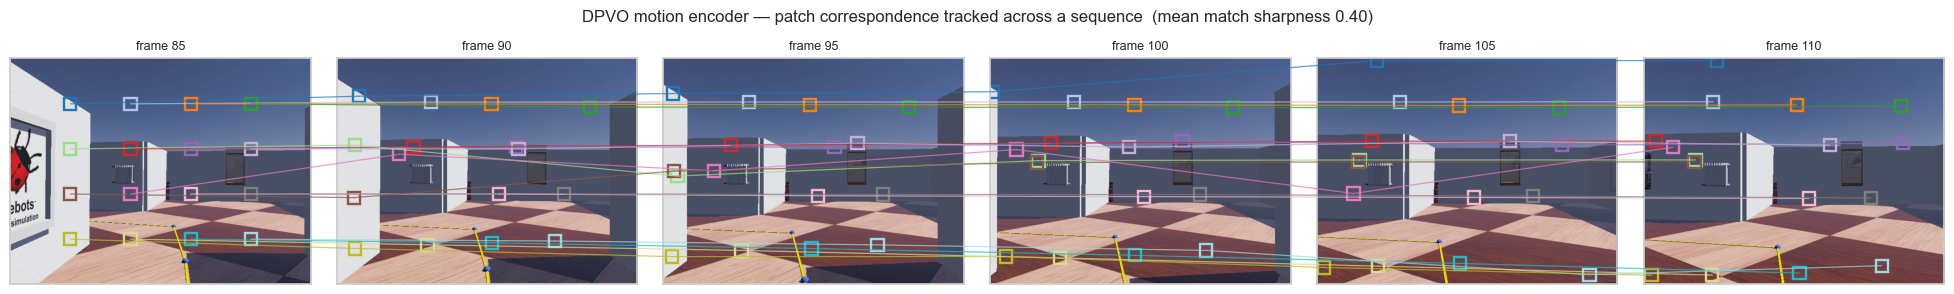

In [9]:
# --- 12.3  DELIVERABLE 3 — patch correspondence across a sequence ---
# Seed points on a grid in frame 0, track them frame-to-frame via the
# encoder's correlation. Coloured boxes = tracked patches; lines link the
# same patch across consecutive frames (DPVO Fig. 1 style).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Rectangle, ConnectionPatch
from PIL import Image
from src.pipeline.training.motion import track_patches

pdir = DATA / "path_02"
cam = pd.read_csv(pdir / "camera.csv")
seq = [85, 90, 95, 100, 105, 110]                       # 6 frames, gap = STRIDE
frame_paths = [pdir / cam.iloc[i]["rgb_path"] for i in seq]

coords, sharp = track_patches(motion_enc, frame_paths, n_track=16, device=device)
T, K, _ = coords.shape
colors = cm.tab20(np.linspace(0, 1, K))
BOX = 26

fig, axes = plt.subplots(1, T, figsize=(3.3 * T, 3.0))
for t, ax in enumerate(axes):
    ax.imshow(np.array(Image.open(frame_paths[t]).convert("RGB")))
    for k in range(K):
        x, y = coords[t, k]
        ax.add_patch(Rectangle((x - BOX / 2, y - BOX / 2), BOX, BOX,
                               fill=False, edgecolor=colors[k], lw=1.7))
    ax.set_title(f"frame {seq[t]}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

# Cross-frame correspondence lines.
for t in range(1, T):
    for k in range(K):
        fig.add_artist(ConnectionPatch(
            coords[t - 1, k], coords[t, k], "data", "data",
            axesA=axes[t - 1], axesB=axes[t],
            color=colors[k], lw=0.9, alpha=0.7))

plt.suptitle("DPVO motion encoder — patch correspondence tracked across "
             f"a sequence  (mean match sharpness {sharp.mean():.2f})",
             fontsize=12)
plt.tight_layout(); plt.show()
